In [1]:
################################################################
## Import libraries
import os
import numpy as np
np.set_printoptions(suppress=True)
import matplotlib.pyplot as plt
import sys
from pathlib import Path
################################################################
src_path = Path().resolve().parent / "src"
sys.path.insert(0, str(src_path))
#################################################################################
import dabest_helper as dbh
import analysis as an
from data_io import load_npy, load_from_text
from plotting import plot_event_raster, plot_psth, plot_individual_event_rasters, cat_plot_clf, plot_single_similarity_matrix
from analysis import generate_mean_sparsity_from_IFR, drop_nan_for_df, corr_metric, find_max_bin_1d, select_random_subset

from my_mpl_defaults import *
import smBaseFunctions3 as sbf
#################################################################################
from plotting import set_plot_style
set_plot_style()
#################################################################################

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 23.83it/s]


Numba compilation complete!


In [2]:
sys.path

['/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src',
 '/usr/lib/python310.zip',
 '/usr/lib/python3.10',
 '/usr/lib/python3.10/lib-dynload',
 '',
 '/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/venv/lib/python3.10/site-packages']

In [3]:
##################################################################################################
BASE_DIR = Path.cwd().parent
path_to_data = 'data/structure/'
fname = 'IFR_all_mice_pdg_p3_p1'
IFR_data = load_npy(BASE_DIR, path_to_data, fname, file_ext='.npy').item()
bsnm_list = list(load_from_text(BASE_DIR, path_to_data, 'bsnm_list', file_ext=".db", dtype=str))
##################################################################################################

Loading from: /Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/data/structure/IFR_all_mice_pdg_p3_p1.npy
Loading from: /Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/data/structure/bsnm_list.db


In [4]:
ikey = 'swr'
mindx = 1
okey = 'pulse'

idict = IFR_data
ikey_list = ['noevent','ds','ds1','ds2','swr']
for indx,ikey in enumerate(ikey_list):
    idata = idict[ikey][mindx][okey]
    print(indx,ikey,okey,idata.shape)

0 noevent pulse (25, 5339)
1 ds pulse (25, 569)
2 ds1 pulse (25, 240)
3 ds2 pulse (25, 352)
4 swr pulse (25, 102)


#### To plot the raster plot examples seen in Figure 3a, see notebooks/Neuron_raw_rasters_github.ipynb

#### Generate data required for Figure 3b and Figure 3c

In [5]:
###############################################################################
event_list = sbf.keys_to_list(IFR_data)
cond_list = ['prepulse','pulse']

sparsity_dict = {}
for ev_indx,event in enumerate(event_list):
    print(ev_indx,event)
    sparsity_dict[event] = generate_mean_sparsity_from_IFR(IFR_data[event],
                                                           cond_list,
                                                           bsnm_list)
    sparsity_dict[event] = drop_nan_for_df(sparsity_dict[event],cond_list)
###############################################################################

0 noevent
1 ds
2 ds1
3 ds2
4 swr


#### Generate sparsity data for baseline periods and during each event type <br> (dentate spikes, ds1, ds2, sharp-wave ripples)
set panel = '3b' to visualize Figure 3b or <br>
set panel = '3c' to visualize Figure 3c

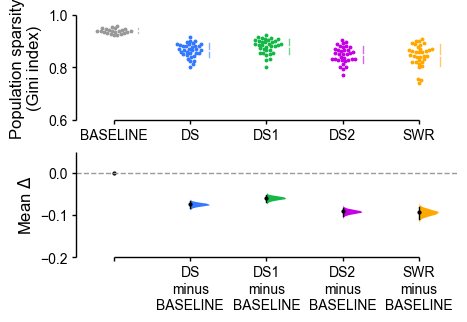

In [6]:
###################################################################################################
panel = '3b'
###################################################################################################
idata = sparsity_dict
size_scale = 2
#### determine columns and conditions to create pandas dataframe from data dictionary #################
innerkey = sbf.keys_to_list(idata)
outerkey = ['prepulse','pulse']
col_head = ['id','Event_Type','Pulse_Type','Data','Event_Pulse']
col_groups = {'noevent':'Baseline',
              'ds':'DS',
              'ds1':'DS1',
              'ds2':'DS2',
              'swr':'SWR',
             }
#### specify the contrasts for plotting and analyses, each row is a within-samples comparison #######
if panel == '3b':
    df_idx = [
                ['Baseline_pulse','DS_pulse','DS1_pulse','DS2_pulse','SWR_pulse'],
             ]
    contrast_ylim = (-0.2,0.05)
    contrast_maj_loc = 0.1

elif panel == '3c':
    df_idx = [
                ['DS2_pulse','SWR_pulse'],
             ]
    contrast_ylim = (-.05,0.05)
    contrast_maj_loc = 0.05

#### create a DABEST analysis object, specify that analyses are within-samples (paired='baseline') ####
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Event_Pulse',
                                                   y='Data')
###########################################################################################################
my_color_palette = dbh.get_event_palette(df_idx)
fig,swarm_ax,contrast_ax = dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                          df_idx,
                                                          show_pairs=False,
                                                          diff_type='mean',
                                                          swlab='Population sparsity\n(Gini index)',
                                                          size_scale=2,
                                                          fwd=1.25,
                                                          fht=4,
                                                          pad=1.5,
                                                          lw=0.5,
                                                          swarm_ylim=(0.6,1),
                                                          contrast_ylim=contrast_ylim,
                                                          swarm_maj_loc=0.2,
                                                          contrast_maj_loc=contrast_maj_loc,
                                                          fscale=(5,6,7),
                                                          raw_marker_size=0.8,
                                                          my_color_palette=my_color_palette)
######################################################################################################################
swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
######################################################################################################################
plt.show()
######################################################################################################################

#### Statistical results

In [7]:
####################################################################################################
analysis_of_long_df.cohens_d.statistical_tests
####################################################################################################

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Baseline_pulse,DS_pulse,34,34,Cohen's d,baseline,-3.768747,95,-4.480536,-3.012079,0.0,1.164153e-10,0.0,1.625357e-18,17.841482
1,Baseline_pulse,DS1_pulse,34,34,Cohen's d,baseline,-2.910508,95,-3.395556,-2.328565,0.0,1.164153e-10,0.0,1.151453e-14,13.142505
2,Baseline_pulse,DS2_pulse,34,34,Cohen's d,baseline,-4.001238,95,-4.782525,-3.127902,0.0,1.164153e-10,0.0,5.641632e-19,18.480216
3,Baseline_pulse,SWR_pulse,34,34,Cohen's d,baseline,-3.126551,95,-3.882584,-2.481079,0.0,1.164153e-10,0.0,2.458499e-14,12.787962


#### Run Logistic Regression classifier to see if the spiking content during dentate spikes differs from that during sharp-wave ripples
This will visualize Figure 3d<br>
To visualize Figure S4d, temp_event_list = ['ds1','swr'], temp_event_list = ['ds1','swr'], or temp_event_list = ['ds1','ds2']

In [8]:
from classifier import run_event_classification 

temp_event_list = ['ds','swr']
all_clf_dat =  run_event_classification(IFR_data,
                                        bsnm_list,
                                        event_list=temp_event_list,
                                        cond_list = ['prepulse','pulse','postpulse'],
                                        clf_type_str = "LogReg",
                                        train_prop = 0.75,
                                        nprs = 100,
                                        match_train_number = True,
                                        binarize = True,
                                        verbose = False)

#### Plot classifier performance for epochs during dentate spikes versus sharp-wave ripples <br>and also for matched-epochs before (pre-event) and after (post-event) as in Figure 3d

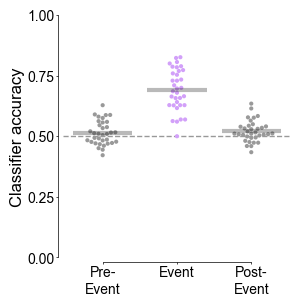

In [9]:
################################################################################
idata = all_clf_dat
################################################################################
innerkey = ['prepulse','pulse','postpulse']
outerkey = ['both']

col_head = ['id','sleep','event','Data','sleep_event']
col_groups = {'prepulse':'pre-event',
              'pulse':'event',
              'postpulse':'post-event'
             }
################################################################################
df = dbh.dabest_long_df_2var(idata,innerkey,outerkey,col_groups,col_head)
################################################################################
figsize = (len(np.unique(df.sleep_event))*2.5,8)
chance_level = 0.5

fig,ax = cat_plot_clf(df,
                      palette=(gray2,LIGHTPURPLE,gray2,PURPLE),
                      hue_col='sleep_event',
                      legend=False,
                      msize=3,
                      figsize=figsize)

ax.axhline(chance_level,linewidth=1,linestyle='--',color=gray2)

## replace x-axis labels
label_list = [x for x in ['Pre-\nEvent', 'Event','Post-\nEvent'] ]
ax.set_xticklabels(label_list, minor=False)

plt.show()
################################################################################################

#### Statistical tests for Event versus Pre-event, and Event versus Post-event

In [10]:
idata = all_clf_dat
df_idx = [['event_both','pre-event_both','post-event_both']]

analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='sleep_event',
                                                   y='Data')
analysis_of_long_df.mean_diff.statistical_tests

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,event_both,pre-event_both,34,34,mean difference,baseline,-0.177211,95,-0.208140,-0.148694,0.0,1.164153e-10,0.0,3.606095e-13,11.583649
1,event_both,post-event_both,34,34,mean difference,baseline,-0.170893,95,-0.201843,-0.138932,0.0,2.328306e-10,1.0,4.855718e-12,10.487047


#### Generate population vector similarity data

#### Use this to generate example matrices in Figure 3e
set bsnm_indx = 16 (for the examples used in manuscript; or set to other value (between 0 and 33) to see matrices from other recording days)

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:783: RuntimeWarning: invalid value encountered in divide
  dist = np.dot(A_mA,B_mB.T)/np.sqrt(np.dot(ssA[:,None],ssB[None]))


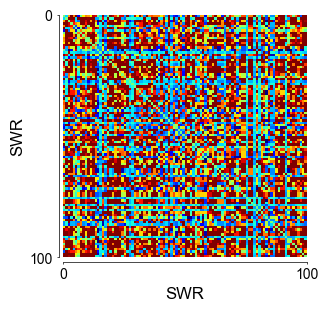

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:783: RuntimeWarning: invalid value encountered in divide
  dist = np.dot(A_mA,B_mB.T)/np.sqrt(np.dot(ssA[:,None],ssB[None]))


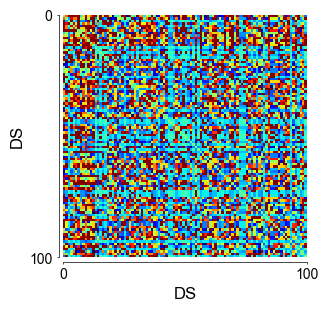

In [11]:
#########################################################################
bsnm_indx = 16 
event_pair_list = [['swr','swr'],['ds','ds']]
for event_1, event_2 in event_pair_list:
    #########################################################################
    sim_mat = an.get_single_similarity_matrix(IFR_data,
                                           bsnm_indx,
                                           event_1,
                                           event_2,
                                           max_bin=an.get_max_bin(event_1)
                                          )
    #########################################################################
    fig,ax = plot_single_similarity_matrix(sim_mat,
                                           event_1,
                                           event_2,
                                           cbar=False,
                                           fwd=8,
                                           fht=8,
                                           size_scale=2,
                                           vlim=(-0.3,0.3),
                                           cmap='jet',
                                           nprs=10,
                                           fscale=(5,6,8)
                                          )
    plt.show()
    ########################################################################

#### Generate data required for Figure 3F and Figure 3G

In [12]:
event_pair_list = [
                    ['noevent','noevent'],
                    ['swr','swr'],
                    ['ds','ds'],
                    ['ds1','ds1'],
                    ['ds2','ds2']
                  ]
PV_sim_dict = an.generate_pv_similarity_data(IFR_data,
                                              bsnm_list,
                                              event_pair_list,
                                              rand_subset = True,
                                              binarize = True,
                                              shuffle_list = [False,True],
                                              event_list=['ds','swr'],
                                              output_dat = 'mean',
                                              cond = 'pulse'
                                              )

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:783: RuntimeWarning: invalid value encountered in divide
  dist = np.dot(A_mA,B_mB.T)/np.sqrt(np.dot(ssA[:,None],ssB[None]))


#### Compare Population vector similarity across baseline, SWR and DS (Figure 3f) <br> or for SWR versus DS1, DS2 (Figure 3g)

In [13]:
###################################################################################################
idata = PV_sim_dict['data']
figure_panel = '3g'
##################################################################################################
innerkey = ['noevent_noevent','swr_swr','ds_ds','ds1_ds1','ds2_ds2']
outerkey = []
col_head = ['id','ikey','Data','Cond_Event']
col_groups = {'noevent_noevent': 'BASE',
              'ds_ds':   'DS',
              'swr_swr': 'SWR',
              'ds1_ds1':   'DS1',
              'ds2_ds2': 'DS2',
             }

if figure_panel == '3f':
    df_idx = [
               ['BASE','SWR','DS'], 
             ]
    contrast_ylim = (-0.06,0.2)
    contrast_maj_loc = 0.1
    
elif figure_panel == '3g':
    df_idx = [
                ['SWR','DS1','DS2'],
             ]
    contrast_ylim = (-0.12,0.06) 
    contrast_maj_loc = 0.06

#### create a DABEST analysis object, specify that analyses are within-samples (paired='baseline') ####
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Cond_Event',
                                                   y='Data')

#### Visualize Figure 3f or 3g

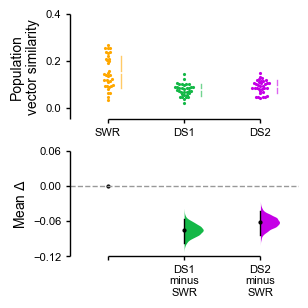

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,SWR,DS1,34,34,mean difference,baseline,-0.074887,95,-0.096379,-0.055354,0.0,5.203765e-08,21.0,5.626682e-08,6.976331
1,SWR,DS2,34,34,mean difference,baseline,-0.061532,95,-0.082950,-0.041774,0.0,2.498738e-06,47.0,2.317078e-06,5.702666


In [14]:
my_color_palette = dbh.get_event_palette(df_idx)
fig,swarm_ax,contrast_ax = dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                          df_idx,
                                                          swlab='Population\nvector similarity',
                                                          size_scale=2,
                                                          fwd=1.25,
                                                          fht=4,
                                                          pad=1.5,
                                                          lw=0.5,
                                                          swarm_ylim=(-.05,.4),
                                                          swarm_maj_loc=0.2,
                                                          contrast_ylim=contrast_ylim,
                                                          contrast_maj_loc=contrast_maj_loc,
                                                          fscale=(4,5,6),
                                                          raw_marker_size=0.4,
                                                          my_color_palette=my_color_palette)

swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
plt.show()
display(analysis_of_long_df.mean_diff.statistical_tests)

#### Load cluster coefficient data

In [43]:
##################################################################################################
BASE_DIR = Path.cwd().parent
path_to_data = 'data/structure/'
fname = 'clust_all_mice'
all_clust_data = load_npy(BASE_DIR, path_to_data, fname, file_ext='.npy').item()
##################################################################################################

Loading from: /Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/data/structure/clust_all_mice.npy


#### Analyse for figure_panel 3k or figure_panel S4k

In [45]:
###################################################################################################
idata = all_clust_data
figure_panel = '3k' #  could be '3k' or 'S4k'
###################################################################################################
innerkey = ['noevent','swr','ds','ds1','ds2']
outerkey = ['prepulse','pulse']
###################################################################################################
col_head = ['id','Event_Type','Sess_Type','Data','Group_sess']
col_groups = {'ds':'DS',
              'swr':'SWR',
              'noevent':'BASE',
              'ds1':'DS1',
              'ds2':'DS2',
             }
###################################################################################################
if figure_panel == '3k':
    df_idx = [['BASE_pulse','SWR_pulse','DS_pulse']]
    contrast_ylim =(0,0.03)
    contrast_maj_loc = 0.015
    my_color_palette = [gray2,ORNG,BLUE]
###################################################################################################    
elif figure_panel == 'S4k':
    df_idx = [['SWR_pulse','DS1_pulse','DS2_pulse']]
    contrast_ylim =(-0.01,0.02)
    contrast_maj_loc = 0.01
    my_color_palette=[ORNG,GREEN,PURPLE]
###################################################################################################
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                               outerkey,
                                               innerkey,
                                               col_head,
                                               col_groups,
                                               df_idx,
                                               paired='baseline',
                                               x='Group_sess',
                                               y='Data',
                                               id_col='id')
###################################################################################################

#### This will generate Figure 3k or Figure S4k, depending on figure_panel choice above

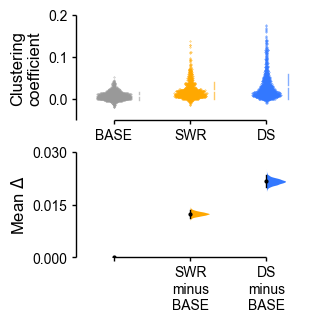

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,BASE_pulse,SWR_pulse,1265,1265,Cohen's d,baseline,0.814608,95,0.755108,0.874017,0.0,3.088399e-90,136668.0,4.404076e-86,-21.272773
1,BASE_pulse,DS_pulse,1265,1265,Cohen's d,baseline,0.967342,95,0.917089,1.017813,0.0,2.274408e-128,86601.0,2.252968e-112,-24.994951


In [46]:
fig,swarm_ax,contrast_ax =  dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                           df_idx,
                                                           show_pairs=False,
                                                           diff_type='mean',
                                                           swlab='Clustering\ncoefficient',
                                                           size_scale=2,
                                                           fwd=1.25,
                                                           fht=4,
                                                           pad=1.5,
                                                           swarm_ylim=(-0.05,0.2),                                                       
                                                           swarm_maj_loc=0.1,
                                                           contrast_ylim=contrast_ylim,
                                                           contrast_maj_loc=contrast_maj_loc,
                                                           fscale=(5,6,7),
                                                           raw_marker_size=0.02,
                                                           jitter=8,
                                                           my_color_palette=my_color_palette)

swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
plt.show()
analysis_of_long_df.cohens_d.statistical_tests

#### Calculate PCA on IFR matrices

enter figure_panel = '3l' or figure_panel = 'S4p'

In [47]:
pc_dict = an.generate_pca(IFR_data,bsnm_list,event_list=['ds','ds1','ds2','swr'],cond='pulse',thrs=0.9,norm=True,min_comp=2)

In [49]:
###################################################################################################
idata = pc_dict
figure_panel = '3l' # or 'S4p'
###################################################################################################
innerkey = ['noevent','swr','ds','ds1','ds2']
outerkey = []
col_head = ['id','ikey','Data','Group_sess']
col_groups = {
              'noevent': 'BASE',
              'ds':   'DS',
              'ds1':  'DS1',
              'ds2':  'DS2',
              'swr': 'SWR',
             }
####################################################################################################
if figure_panel == '3l':
    df_idx = [['SWR','DS']]
    contrast_ylim = (-0.03,0.1)
    contrast_maj_loc = 0.1
    my_color_palette=[ORNG,BLUE]
###################################################################################################    
elif figure_panel == 'S4p':
    df_idx = [['SWR','DS1','DS2']]
    contrast_ylim = (-0.1,0.1)
    contrast_maj_loc = 0.1
    my_color_palette=[ORNG,GREEN,PURPLE]

analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Group_sess',
                                                   y='Data',
                                                   id_col='id')
#####################################################################################################

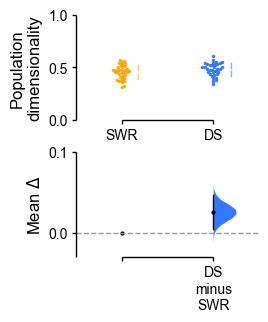

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,SWR,DS,34,34,Cohen's d,baseline,0.398946,95,0.057859,0.726355,0.0234,0.032486,100.0,0.021526,-2.413229


In [50]:
fig,swarm_ax,contrast_ax =  dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                           df_idx,
                                                           show_pairs=False,
                                                           diff_type='mean',
                                                           swlab='Population\ndimensionality',
                                                           size_scale=2,
                                                           fwd=1.5,
                                                           fht=4,
                                                           pad=1.5,
                                                           swarm_ylim=(0,1.0),                                                       
                                                           swarm_maj_loc=0.5,
                                                           contrast_ylim=contrast_ylim,
                                                           contrast_maj_loc=contrast_maj_loc,
                                                           fscale=(5,6,7),
                                                           raw_marker_size=0.5,
                                                           my_color_palette=my_color_palette)

swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
plt.show()
analysis_of_long_df.cohens_d.statistical_tests

#### end here